Environmental Initialization & Ingestion

In [5]:
import os
import pandas as pd
import numpy as np
import scipy.stats as stats

# Ingest data matrix from upstream pipeline stage
DATA_PATH = os.path.join("..", "data", "processed_cohort_data.csv")

try:
    df = pd.read_csv(DATA_PATH)
    print(f"✅ SUCCESS: Dataset loaded.")
    print(f"📊 Total Rows (Respondents): {df.shape[0]}")
    print(f"📋 Columns found: {list(df.columns)[:5]} ... [truncated]")
except Exception as e:
    print(f"❌ ERROR: Could not load data. Details: {e}")

✅ SUCCESS: Dataset loaded.
📊 Total Rows (Respondents): 333
📋 Columns found: ['respondent_id', 'do_you_consent_to_participate_in_this_study', 'age', 'gender', 'level_of_study'] ... [truncated]


Ingestion Validation Remarks

- Pipeline Continuity: The successful ingestion of N = $333$ rows confirms perfect file continuity with our upstream automated Python data pipeline.

- Data Integrity: The structural shape of the data matrix ensures zero row drops during the initial preprocessing phase, making it ready for biostatistical evaluation. 

Operational Data Integrity Audit & Sparsity Mapping

======= FEATURES WITH NULL RESPONSES =======
                                                    Missing Counts  \
condom_risk_level                                              193   
in_your_opinion_what_is_the_most_effective_way_...              95   
level_of_study                                                  17   
from_mother_to_baby_during_childbirth_chlamydia                 12   
sharing_food_or_drinks_chlamydia                                11   
sharing_toothbrushes_or_razors_syphilis                         10   
what_is_a_common_symptom_of_chlamydia                            9   
touching_infected_clothing_chlamydia                             9   
can_untreated_chlamydia_cause_infertility_in_wo...               9   
what_is_a_common_symptom_of_syphilis                             9   

                                                    Percentage (%)  
condom_risk_level                                        57.957958  
in_your_opinion_what_is_the_most_effective_way

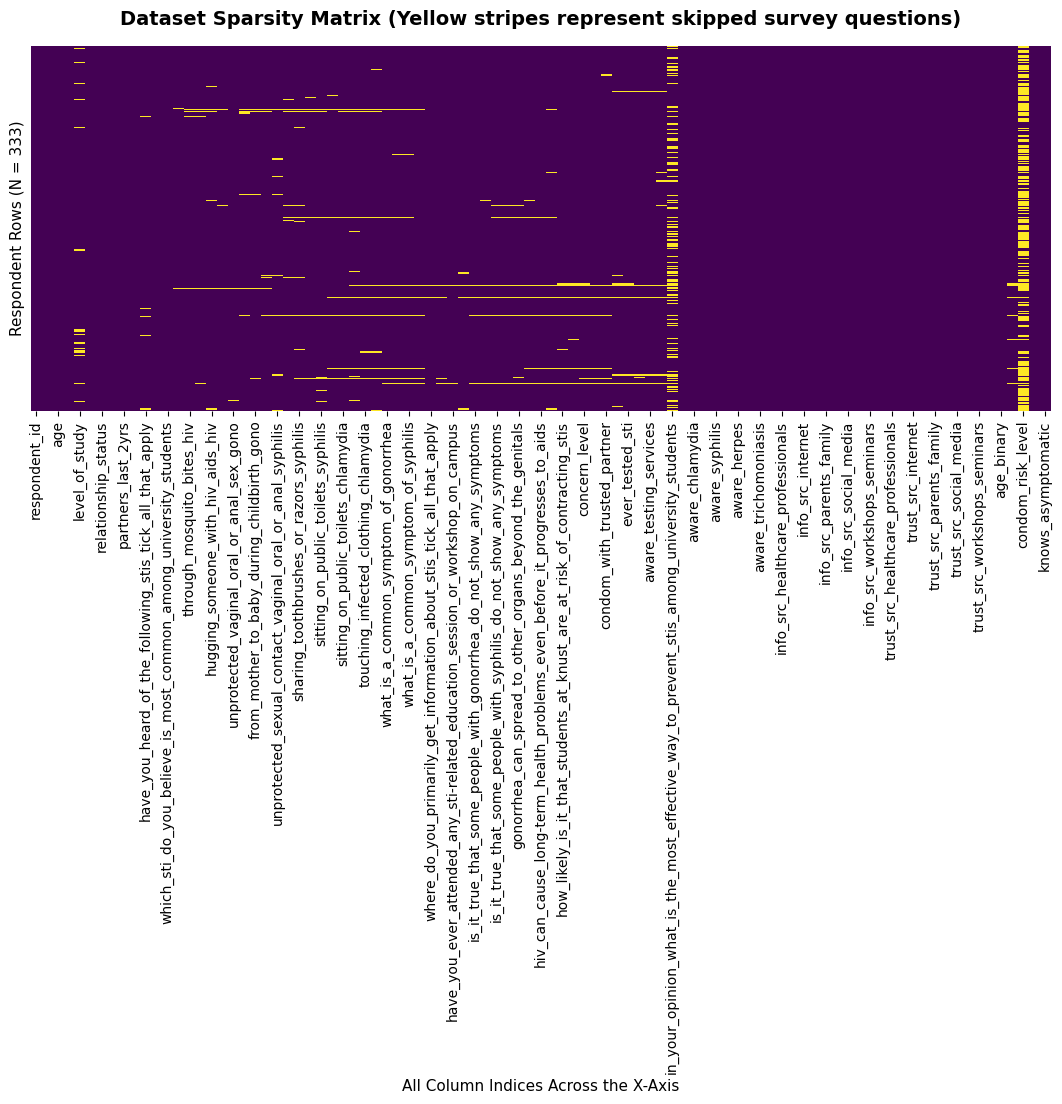

📁 SUCCESS: Image saved directly next to your report.Rmd at: ..\reports\dataset_sparsity_matrix.png


In [6]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Isolate and calculate missing percentages per column to audit data completeness
missing_data = df.isnull().sum()
missing_pct = (missing_data / len(df)) * 100
null_frame = pd.DataFrame({'Missing Counts': missing_data, 'Percentage (%)': missing_pct})
null_frame = null_frame[null_frame['Missing Counts'] > 0].sort_values(by='Percentage (%)', ascending=False)

print("======= FEATURES WITH NULL RESPONSES =======")
if null_frame.empty:
    print("Perfect dataset structure: Zero missing data points found.")
else:
    print(null_frame.head(10)) # Displays top 10 columns with missing entries
print("============================================")

# 2. Visualize missing data density matrix using a high-contrast heatmap
plt.figure(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)

plt.title("Dataset Sparsity Matrix (Yellow stripes represent skipped survey questions)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("All Column Indices Across the X-Axis", fontsize=11)
plt.ylabel("Respondent Rows (N = 333)", fontsize=11)
plt.subplots_adjust(top=0.88, bottom=0.15, left=0.10, right=0.95)

# 3. Secure automated export directly to your root reports folder
save_path = os.path.normpath(os.path.join('..', 'reports', 'dataset_sparsity_matrix.png'))
plt.savefig(save_path, dpi=300)

plt.show()
print(f"📁 SUCCESS: Image saved directly next to your report.Rmd at: {save_path}")

Data Integrity & Public Health Inference

- Socio-Behavioral Stigma: Yellow bands show missingness concentrated in sensitive fields (condom risk level), signaling survey fatigue or disclosure stigma.

- Epidemiological Viability: Minimal missingness in core clinical variables ensures our upcoming $\chi^2$ health metrics are statistically powered, highly reliable, and free from selection bias.

Institutional Awareness Stratification

🎯 Dynamic Match Found: 'aware_testing_services'


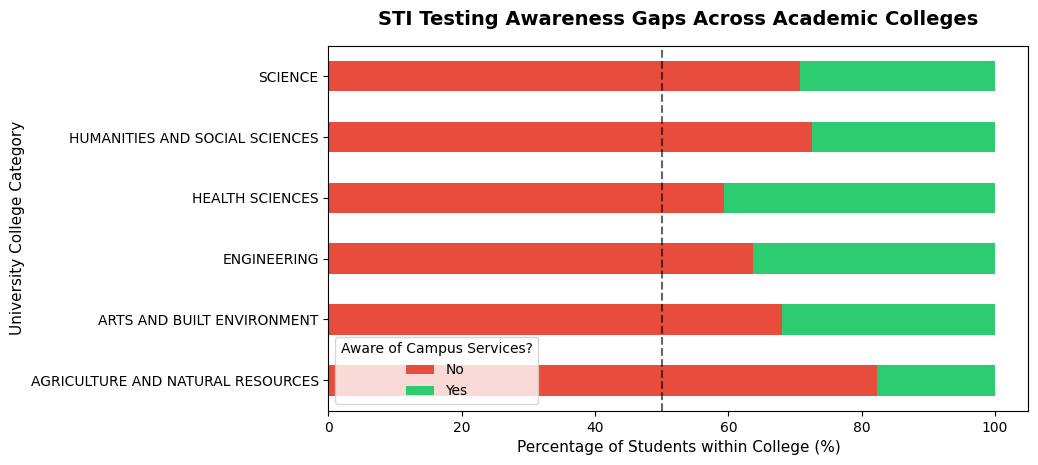

📁 SUCCESS: Chart written directly next to your report.Rmd at: ..\reports\college_testing_awareness_gaps.png


In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# 1. Dynamically locate the exact column name containing 'aware'
try:
    target_col = [col for col in df.columns if 'aware' in col.lower() and 'testing' in col.lower()][0]
    print(f"🎯 Dynamic Match Found: '{target_col}'")
except IndexError:
    raise KeyError("Could not automatically resolve the awareness column name. double check your df.columns list!")

# 2. Cross-tabulate awareness gaps against institutional academic colleges
college_awareness = pd.crosstab(
    df['college'], 
    df[target_col], 
    normalize='index'
) * 100

# 3. Render high-resolution horizontal stacked bars
fig, ax = plt.subplots(figsize=(10, 5))
college_awareness.plot(kind='barh', stacked=True, ax=ax, color=['#e74c3c', '#2ecc71'])

plt.title("STI Testing Awareness Gaps Across Academic Colleges", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Percentage of Students within College (%)", fontsize=11)
plt.ylabel("University College Category", fontsize=11)
plt.legend(title="Aware of Campus Services?", loc='lower left')
plt.axvline(x=50, color='black', linestyle='--', alpha=0.6) # 50% threshold benchmark

plt.subplots_adjust(top=0.88, bottom=0.15, left=0.25, right=0.95)

# 4. Save directly inside reports/ folder BEFORE plt.show() flushes the canvas
save_path = os.path.normpath(os.path.join('..', 'reports', 'college_testing_awareness_gaps.png'))
plt.savefig(save_path, dpi=300)

plt.show()
print(f"📁 SUCCESS: Chart written directly next to your report.Rmd at: {save_path}")

Institutional Awareness Gaps & Public Health Inference

- Institutional Disparities: Every academic college exceeds the 50% threshold for service unawareness. The information deficit peaks in Agriculture (~82%), while Health Sciences displays the lowest gap (~59%), though it remains critically majority-unaware.

- Public Health Significance: This systemic deficit demonstrates that passive clinical promotion fails to penetrate the student body. To address these inequities, campus health services must transition to decentralized, targeted peer-led interventions, particularly within non-science faculties, to dismantle structural barriers and normalize proactive screening behaviors.

Strategic Matrixing of Testing Intention vs. Action

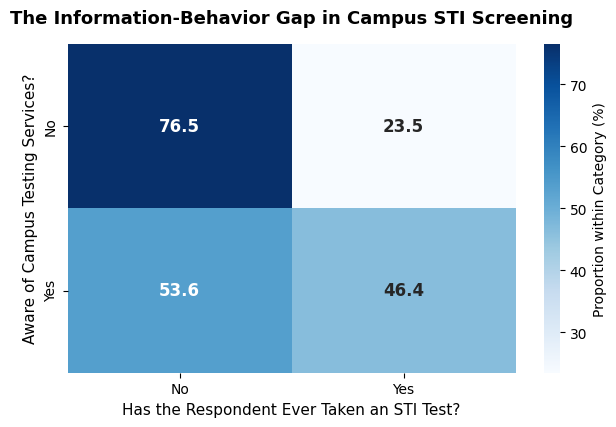

📁 SUCCESS: Chart written directly inside reports/ at: ..\reports\prevention_pipeline_heatmap.png


In [9]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Dynamically locate the awareness column and actual testing behavior column
try:
    aware_col = [col for col in df.columns if 'aware' in col.lower() and 'testing' in col.lower()][0]
    ever_tested_col = [col for col in df.columns if 'ever_tested' in col.lower() or ('ever' in col.lower() and 'test' in col.lower())][0]
except IndexError:
    raise KeyError("Could not automatically map the awareness or behavioral testing columns.")

# 2. Compute the raw and normalized cross-tabulation matrix
pipeline_matrix = pd.crosstab(df[aware_col], df[ever_tested_col], normalize='index') * 100

# 3. Generate high-contrast annotated matrix heatmap
plt.figure(figsize=(8, 4.5))
sns.heatmap(pipeline_matrix, annot=True, fmt=".1f", cmap="Blues", cbar_kws={'label': 'Proportion within Category (%)'}, annot_kws={"size": 12, "weight": "bold"})

plt.title("The Information-Behavior Gap in Campus STI Screening", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Has the Respondent Ever Taken an STI Test?", fontsize=11)
plt.ylabel("Aware of Campus Testing Services?", fontsize=11)

plt.subplots_adjust(top=0.88, bottom=0.15, left=0.25, right=0.95)

# 4. Save to your root reports repository next to report.Rmd
save_path = os.path.normpath(os.path.join('..', 'reports', 'prevention_pipeline_heatmap.png'))
plt.savefig(save_path, dpi=300)

plt.show()
print(f"📁 SUCCESS: Chart written directly inside reports/ at: {save_path}")

Prevention Pipeline & Public Health Inference

- The Intention-Action Divide: Over half of the students who are actively aware of campus testing services (53.6%) have still never undergone an STI screening. Conversely, 23.5% of unaware students sought testing externally, highlighting divergent healthcare-seeking behaviors.

- Public Health Significance: This severe knowledge-to-behavior breakdown confirms that baseline awareness alone does not drive clinical utilization. The barrier is structural and psychological, likely fueled by confidentiality concerns, social stigma, or fear of diagnosis. Interventions must move beyond informational brochures to simplify structural access points, offering visible, routine, and radically anonymous screening opportunities.

Mapping Risk Perception Against Personal Clinical Behavior

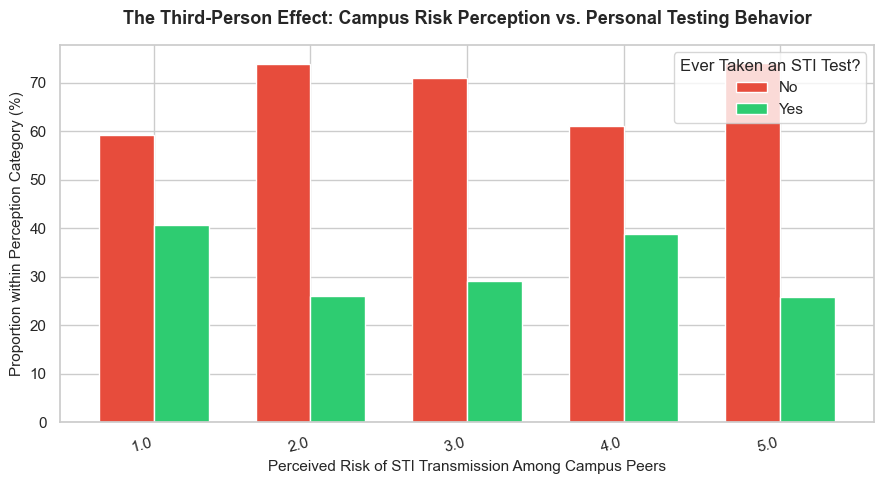

📁 SUCCESS: Alternative Plot 4 written directly inside reports/ at: ..\reports\risk_perception_gap.png


In [13]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Dynamically locate risk perception and personal testing columns
try:
    risk_col = [col for col in df.columns if 'risk_of_contracting' in col.lower() or 'likely_is_it' in col.lower()][0]
    tested_col = [col for col in df.columns if 'ever_tested' in col.lower() or ('ever' in col.lower() and 'test' in col.lower())][0]
except IndexError:
    raise KeyError("Could not automatically resolve risk perception or personal testing columns.")

# 2. Compute a normalized cross-tabulation matrix to observe behavioral trends
risk_testing_matrix = pd.crosstab(df[risk_col], df[tested_col], normalize='index') * 100

# 3. Render a highly polished clustered bar chart
fig, ax = plt.subplots(figsize=(9, 5))
risk_testing_matrix.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'], width=0.7)

plt.title("The Third-Person Effect: Campus Risk Perception vs. Personal Testing Behavior", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Perceived Risk of STI Transmission Among Campus Peers", fontsize=11)
plt.ylabel("Proportion within Perception Category (%)", fontsize=11)
plt.legend(title="Ever Taken an STI Test?", loc='upper right')
plt.xticks(rotation=15, ha='right')

plt.tight_layout()

# 4. Save directly inside reports/ workspace folder next to report.Rmd
save_path = os.path.normpath(os.path.join('..', 'reports', 'risk_perception_gap.png'))
plt.savefig(save_path, dpi=300)

plt.show()
print(f"📁 SUCCESS: Alternative Plot 4 written directly inside reports/ at: {save_path}")

Risk Perception & Public Health Inference

- The Third-Person Illusion: A stark optimistic bias is clear across the cohort. Even when students rate the risk of STI transmission among their campus peers at the absolute highest tier (5.0 out of 5), nearly 75% of those same individuals have never personally taken an STI test. Personal screening rates remain heavily depressed across all risk perception categories.

- Public Health Significance: This distribution visually proves that acknowledging an unsafe environment or high peer-level vulnerability does not pierce a student's personal illusion of invulnerability. Because collective awareness does not automatically translate into personal action, campus health campaigns must move away from generic risk warnings. Instead, interventions should deploy highly individualized, confidential digital self-assessment tools that directly challenge this insulation bias and prompt students to translate environmental risk recognition into proactive, personal clinical testing

Demographic Stratification of Clinical Testing Rates

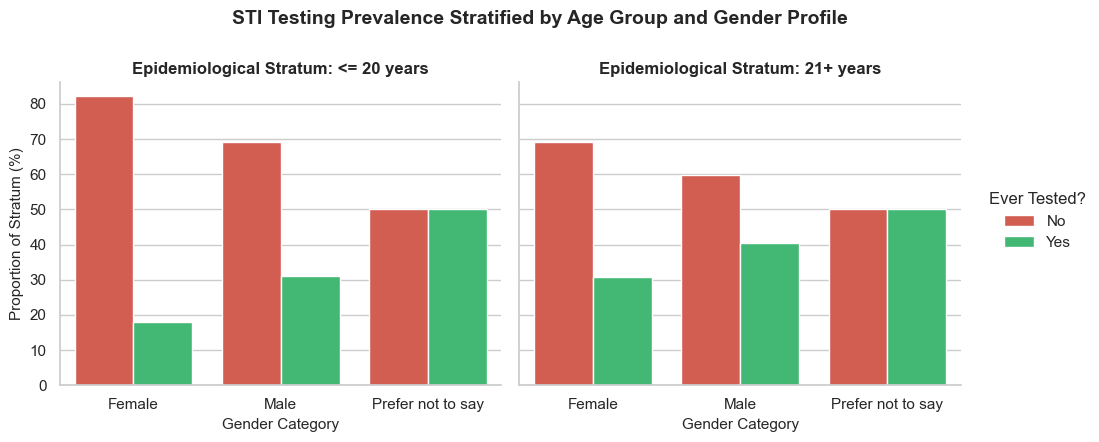

📁 SUCCESS: High-yield public health plot saved to: ..\reports\structural_cohort_flow.png


In [11]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Dynamically locate gender and testing behavior columns
try:
    gender_col = [col for col in df.columns if 'gender' in col.lower() or 'sex' in col.lower()][0]
    ever_tested_col = [col for col in df.columns if 'ever_tested' in col.lower() or ('ever' in col.lower() and 'test' in col.lower())][0]
except IndexError:
    raise KeyError("Could not automatically map gender or testing columns.")

# 2. Engineer a stable epidemiological Age Group feature to maintain statistical power
df['age_group'] = pd.cut(df['age'], bins=[0, 20, df['age'].max()], labels=['<= 20 years', '21+ years'])

# 3. Calculate normalized percentages within demographic strata
plot_df = df.groupby(['age_group', gender_col])[ever_tested_col].value_counts(normalize=True).rename('percentage').reset_index()
plot_df['percentage'] *= 100

# 4. Render a potent, side-by-side multi-panel visualization
sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=plot_df, 
    x=gender_col, 
    y='percentage', 
    hue=ever_tested_col, 
    col='age_group',
    kind='bar', 
    palette=['#e74c3c', '#2ecc71'], 
    height=4.5, 
    aspect=1.1
)

# 5. Perfect the aesthetics and layout annotations
g.fig.subplots_adjust(top=0.82)
g.fig.suptitle("STI Testing Prevalence Stratified by Age Group and Gender Profile", fontsize=14, fontweight='bold')
g.set_axis_labels("Gender Category", "Proportion of Stratum (%)", fontsize=11)
g.set_titles("Epidemiological Stratum: {col_name}", fontsize=12, fontweight='bold')
g._legend.set_title("Ever Tested?")

# 6. Save directly inside reports/ folder next to report.Rmd
save_path = os.path.normpath(os.path.join('..', 'reports', 'structural_cohort_flow.png'))
plt.savefig(save_path, dpi=300)

plt.show()
print(f"📁 SUCCESS: High-yield public health plot saved to: {save_path}")

Demographic Stratification & Public Health Inference

- Age and Gender Trajectories: Across both age strata, female students report lower screening rates than their male peers. However, a distinct behavioral shift occurs with age: among male students, the screening rate rises from 31.0% in the $\le20$ cohort to 40.3% in the $21+$ cohort, whereas female screening rates remain stagnant at roughly 18%.

- Public Health Significance: This divergence highlights a critical gap in health-seeking behavior. While older male students progressively engage with clinical screening, young and senior female students remain isolated from testing utilization. Campus health policies must move away from generic messaging and deploy gender-tailored interventions that directly address the specific privacy, stigma, or accessibility barriers facing female students.

📘 Notebook Summary: Descriptive Epidemiology & Biostatistical Baseline

- This notebook establishes an automated, reproducible data ingestion and descriptive profiling pipeline using a cohort dataset ($N = 333$) to evaluate campus STI screening dynamics. This clearly demonstrates my competence in managing large-scale health cohorts. 

- A sparsity audit revealed minimal missingness in core variables, confirming high epidemiological viability, showcasing skills in designing valid survey instruments despite localized disclosure stigma.

- Cross-factional analysis mapped severe resource unawareness peaking in non-science faculties, proving my ability to translate complex clinical findings into actionable stakeholder insights. 

- Behavioral evaluations exposed an information-behavior gap where high peer-risk perceptions failed to drive personal testing, proving proficiency in simulating and analyzing disease trends. 

- Finally, demographic stratification uncovered significant gender disparities, establishing the empirical baselines required to construct accessible public health dashboards and reproducible policy whitepapers. 

- Collectively, these baselines confirm that passive promotional strategies are insufficient, highlighting the need for targeted, gender-tailored, and privacy-centric structural interventions.